In [1]:
from preprocessing import get_patch_list, get_labels, get_combined_generator, MultimodalDataGenerator
from models import build_model

from config import *

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, RocCurveDisplay
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import os
import random
import warnings

from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")

In [5]:
import codecarbon as lib
print(lib.__version__)

3.0.8


# Parameters

In [3]:
NUM_CLASSES = 1
IMAGE_SIZE = 128

# DATA
BATCH_SIZE = 8

# OPTIMIZER
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001

# TRAINING
EPOCHS = 50

In [4]:
train_patches_dir = "../../donnees_terrain/donnees_modifiees/train_test_split/train_test_split_100m/train_patches/"
val_patches_dir = "../../donnees_terrain/donnees_modifiees/train_test_split/train_test_split_100m/val_patches/"
test_patches_dir = "../../donnees_terrain/donnees_modifiees/train_test_split/train_test_split_100m/test_patches/"

sites = ["fao", "timbertiere", "cisse", "louroux"]
variables = ["SR_MS_patches", "IGN_DTM_patches", "IGN_DSM_patches"]
distance = [100]

order = "trichoptera"

# Import and split data paths

In [5]:
train_patches = np.stack([get_patch_list(train_patches_dir, i, sites=sites, distances=distance) for i in variables], axis=-1)
test_patches = np.stack([get_patch_list(test_patches_dir, i, sites=sites, distances=distance) for i in variables], axis=-1)
val_patches = np.stack([get_patch_list(val_patches_dir, i, sites=sites, distances=distance) for i in variables], axis=-1)

train_image_patches = get_patch_list(train_patches_dir, "S2_MS_patches", sites=sites)
test_image_patches = get_patch_list(test_patches_dir, "S2_MS_patches", sites=sites)
val_image_patches = get_patch_list(val_patches_dir, "S2_MS_patches", sites=sites)

In [6]:
train_patches.shape, test_patches.shape, val_patches.shape

((124, 3), (41, 3), (31, 3))

In [7]:
df_labels = pd.read_csv('../labels_rsec2026.csv', index_col="Unnamed: 0")

In [8]:
train_labels = get_labels(df_labels, train_image_patches, order)
test_labels = get_labels(df_labels, test_image_patches, order)
val_labels = get_labels(df_labels, val_image_patches, order)

In [9]:
train_selected_indices = random.sample(range(len(train_labels)), len(train_labels))
test_selected_indices = random.sample(range(len(test_labels)), len(test_labels))
val_selected_indices = random.sample(range(len(val_labels)), len(val_labels))

In [10]:
train_patches = [train_patches[i] for i in train_selected_indices]
train_labels = [train_labels[i] for i in train_selected_indices]

val_patches = [val_patches[i] for i in val_selected_indices]
val_labels = [val_labels[i] for i in val_selected_indices]

test_patches = [test_patches[i] for i in test_selected_indices]
test_labels = [test_labels[i] for i in test_selected_indices]

In [11]:
labels = train_labels + val_labels + test_labels
print(f"proportion of Ephemeropteres in whole dataset: {round(np.sum(np.array(labels) > 0)/len(labels), 3)}%")
print(f"proportion of Ephemeropteres in train dataset: {round(np.sum(np.array(train_labels) > 0)/len(train_labels), 3)}%")
print(f"proportion of Ephemeropteres in val dataset: {round(np.sum(np.array(val_labels) > 0)/len(val_labels), 3)}%")
print(f"proportion of Ephemeropteres in test dataset: {round(np.sum(np.array(test_labels) > 0)/len(test_labels), 3)}%")

proportion of Ephemeropteres in whole dataset: 0.393%
proportion of Ephemeropteres in train dataset: 0.371%
proportion of Ephemeropteres in val dataset: 0.387%
proportion of Ephemeropteres in test dataset: 0.463%


# Load and preprocess data

In [12]:
if distance[0] == 70:
    default_resize = {
        "MS": 8 if "S2_MS_patches" in variables else 128,
        "DEM": 140 if "IGN_DTM_patches" in variables else 128, 
    }
elif distance[0] == 100:
    default_resize = {
        "MS": 11 if "S2_MS_patches" in variables else 128,
        "DEM": 200 if "IGN_DTM_patches" in variables else 128, 
    }
elif distance[0] == 40:
    default_resize = {
        "MS": 4 if "S2_MS_patches" in variables else 128,
        "DEM": 80 if "IGN_DTM_patches" in variables else 128, 
    }

expected_bands_dict = {
    'S2_MS_patches': [4],  
    'S2_RE_patches': [1],        
    'drone_MS_patches': [5, 10],
    "SR_MS_patches": [4]
}

In [13]:
train_gen = get_combined_generator(
    img_paths=train_patches, batch_size=8, labels=train_labels, mixup_second_gen=True, ms_size=40, dem_size=200,
)
test_gen = MultimodalDataGenerator(
    img_paths=test_patches, batch_size=8, labels=test_labels, shuffle=False, ms_size=40,  dem_size=200,
)
val_gen = MultimodalDataGenerator(
    img_paths=val_patches, batch_size=8, labels=val_labels, shuffle=False, ms_size=40,  dem_size=200,
)

In [14]:
batch = train_gen.__getitem__(0)

In [15]:
batch[0][0].shape, batch[0][1].shape

((8, 40, 40, 4), (8, 200, 200, 2))

In [16]:
batch[1]

array([1.        , 0.86131626, 0.        , 1.        , 0.13502431,
       0.        , 1.        , 0.        ])

In [17]:
idx = 1

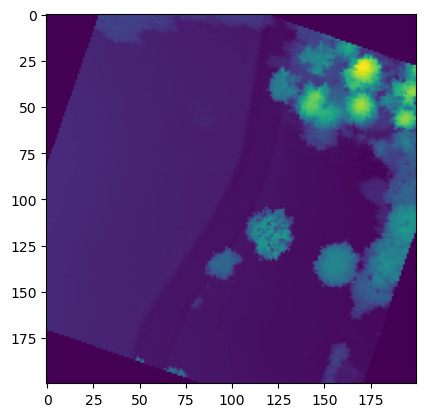

In [18]:
plt.imshow(batch[0][1][idx,:,:,1])

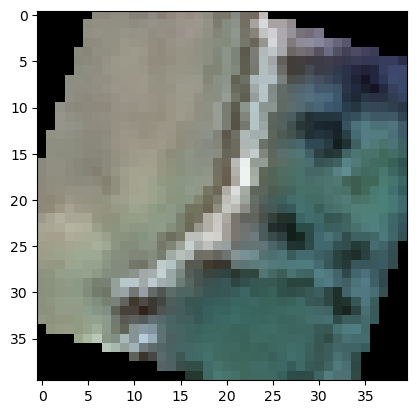

In [19]:
plt.imshow(batch[0][0][idx,:,:,:3])

# Define and compile model

In [20]:
# Example usage
model = build_model(single_sensor=False, ms_shape=(40, 40, 4), lidar_shape=(200, 200, 2), num_classes=1)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ cerberuscnn_input             │ (None, 200, 200, 2)       │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 200, 200, 32)      │             608 │ cerberuscnn_input[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 200, 200, 32)      │           1,632 │ cerberuscnn_input[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 200, 200, 32)      │           3,168 │ cerberuscnn_input[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 100, 100, 32)      │               0 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 50, 50, 32)        │               0 │ conv2d_4[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 25, 25, 32)        │               0 │ conv2d_6[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ tinycerberuscnn_input         │ (None, 40, 40, 4)         │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 100, 100, 32)      │             128 │ max_pooling2d[0][0]        │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 50, 50, 32)        │             128 │ max_pooling2d_2[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 25, 25, 32)        │             128 │ max_pooling2d_4[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 40, 40, 64)        │             320 │ tinycerberuscnn_input[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 40, 40, 64)        │           2,368 │ tinycerberuscnn_input[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_2    │ (None, 4)                 │               

 Total params: 229,153 (895.13 KB)

 Trainable params: 228,577 (892.88 KB)

 Non-trainable params: 576 (2.25 KB)

In [21]:
optimizer = AdamW(
    learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name='auc')
        # keras.metrics.SparseTopKCategoricalAccuracy(2, name="top-2-accuracy"),
    ],
)

# Train model

In [22]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=max([5, EPOCHS//10]), restore_best_weights=True),
            ]

tracker = EmissionsTracker(experiment_id='CO2_tracking', 
                           measure_power_secs=180, 
                           allow_multiple_runs=True)
tracker.start()
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


[codecarbon WARNING @ 16:01:18] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:01:18] [setup] RAM Tracking...
[codecarbon INFO @ 16:01:18] [setup] CPU Tracking...
[codecarbon WARNING @ 16:01:19] We saw that you have a Intel(R) Core(TM) Ultra 5 135H but we don't know it. Please contact us.
[codecarbon WARNING @ 16:01:19] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 16:01:19] CPU Model on constant consumption mode: Intel(R) Core(TM) Ultra 5 135H
[codecarbon WARNING @ 16:01:19] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 16:01:19] [setup] GPU Tracking...
[codecarbon INFO @ 16:01:21] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 16:01:21] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: 

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 337ms/step - accuracy: 0.4435 - auc: 0.5972 - loss: 0.7652 - val_accuracy: 0.6129 - val_auc: 0.5154 - val_loss: 0.6714
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.4718 - auc: 0.6237 - loss: 0.6791 - val_accuracy: 0.6129 - val_auc: 0.7588 - val_loss: 0.6590
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.4798 - auc: 0.6719 - loss: 0.6607 - val_accuracy: 0.6129 - val_auc: 0.8004 - val_loss: 0.6460
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.5282 - auc: 0.7110 - loss: 0.6605 - val_accuracy: 0.6129 - val_auc: 0.7982 - val_loss: 0.6393
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 213ms/step - accuracy: 0.5000 - auc: 0.6984 - loss: 0.6612 - val_accuracy: 0.6452 - val_auc: 0.7939 - val_loss: 0.6566
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.4919 - auc: 0.7193 - loss: 0.6335 - val_accuracy: 0.6129 - val_auc: 0.6798 - val_loss: 0.6803
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6

In [23]:
emissions: float = tracker.stop()
print(f'{emissions*1000}g CO2eq')

[codecarbon INFO @ 16:03:44] Energy consumed for RAM : 0.000794 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 16:03:44] Delta energy consumed for CPU with constant : 0.001686 kWh, power : 42.5 W
[codecarbon INFO @ 16:03:44] Energy consumed for All CPU : 0.001686 kWh
[codecarbon INFO @ 16:03:46] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 0.26974655260433233 W
[codecarbon INFO @ 16:03:46] 0.002491 kWh of electricity and 0.000000 L of water were used since the beginning.


0.009806894498573098g CO2eq


# Evaluate model

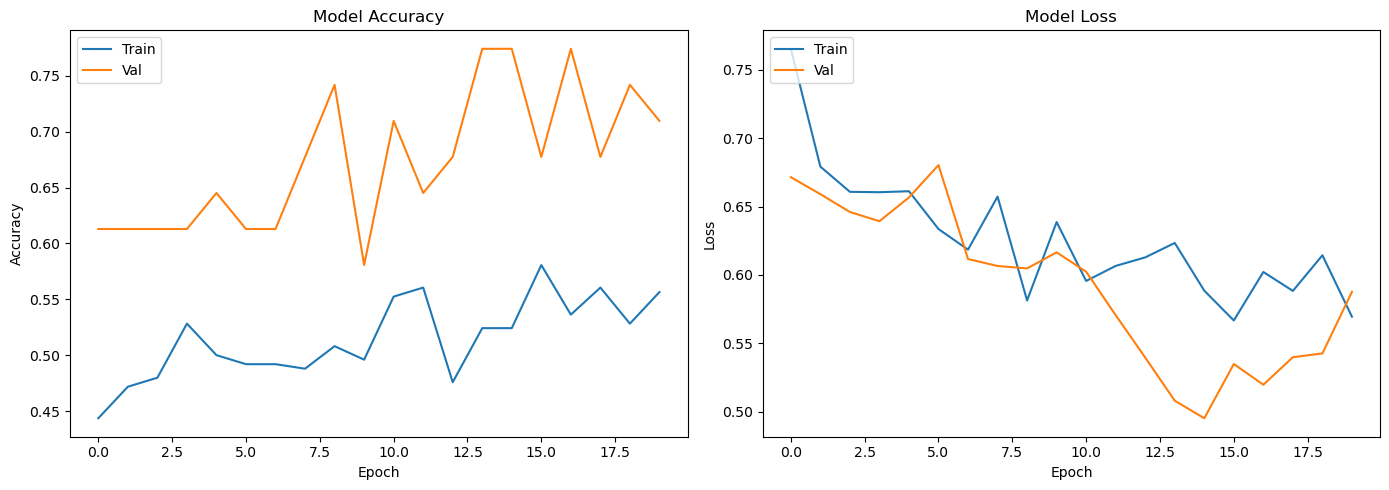

In [25]:
# Create a figure with a row of two subplots
plt.figure(figsize=(14, 5))

# Plot accuracy on the first subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Plot loss on the second subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
# plt.ylim((0, np.min([5, np.max([history.history['loss'], history.history['val_loss']])])))
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Show the plots
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


In [24]:
loss, accuracy, auc = model.evaluate(test_gen)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test AUC: {round(auc, 4)}%")
print(f"Test loss: {round(loss, 5)}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.7317 - auc: 0.8122 - loss: 0.5621
Test accuracy: 73.17%
Test AUC: 0.8122%
Test loss: 0.56212


In [26]:
predictions = model.predict(test_gen)
y_preds = (predictions >= 0.5).astype(int).flatten()
y_true = np.concatenate([y for _, y in test_gen], axis=0) # [int(i > 0) for i in y_test]#

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step


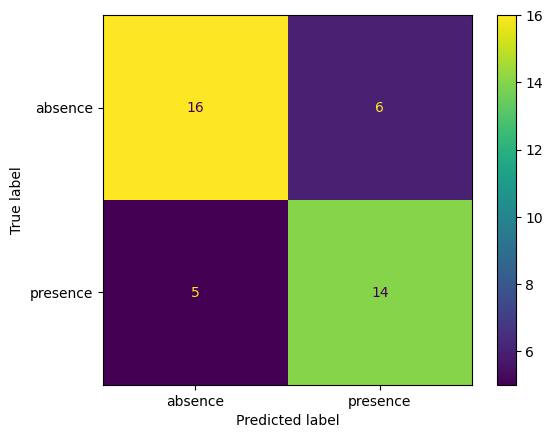

In [29]:
conf_mat = confusion_matrix(["presence" if i==1 else "absence" for i in y_true], ["presence" if i==1 else "absence" for i in y_preds])
disp = ConfusionMatrixDisplay(conf_mat, display_labels=["absence", "presence"])
disp.plot()

In [30]:
print(classification_report(y_true, y_preds, target_names=["absence", "presence"]))

              precision    recall  f1-score   support

     absence       0.76      0.73      0.74        22
    presence       0.70      0.74      0.72        19

    accuracy                           0.73        41
   macro avg       0.73      0.73      0.73        41
weighted avg       0.73      0.73      0.73        41



In [31]:
from sklearn import metrics

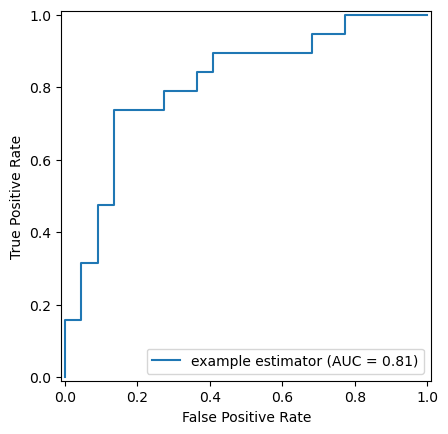

In [32]:
fpr, tpr, thresholds = roc_curve(y_true, predictions.flatten())
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()